[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train YOLOv10 Object Detection on a Custom Dataset

---

[![arXiv](https://img.shields.io/badge/arXiv-2405.14458-b31b1b.svg)](https://arxiv.org/pdf/2405.14458.pdf)
[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/THU-MIG/yolov10)
[![Hugging Face Spaces](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-Spaces-blue)](https://huggingface.co/spaces/SkalskiP/YOLO-ARENA)

YOLOv10 is a new generation in the YOLO series for real-time end-to-end object detection. It aims to improve both the performance and efficiency of YOLOs by eliminating the need for non-maximum suppression (NMS) and optimizing model architecture comprehensively. This advancement reduces computational overhead, enhancing both efficiency and capability. YOLOv10 shows state-of-the-art performance and efficiency, with YOLOv10-S being 1.8 times faster than RT-DETR-R18 and having significantly fewer parameters and FLOPs. Additionally, YOLOv10-B demonstrates 46% less latency and 25% fewer parameters compared to YOLOv9-C while maintaining the same performance.

<p align="center">
  <img src="https://storage.googleapis.com/com-roboflow-marketing/notebooks/examples/yolov10_latency.svg" width=48%>
  <img src="https://storage.googleapis.com/com-roboflow-marketing/notebooks/examples/yolov10_params.svg" width=48%> <br>
  Comparisons with others in terms of latency-accuracy (left) and size-accuracy (right) trade-offs.
</p>

## Pro Tip: Use GPU Acceleration

If you are running this notebook in Google Colab, navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`. This will ensure your notebook uses a GPU, which will significantly speed up model training times.

## Steps in this Tutorial

In this tutorial, we are going to cover:

- Before you start
- Install YOLOv10
- Download pre-trained weights
- Download example data
- Inference with Pre-trained COCO Model
- Download dataset from Roboflow Universe
- Custom Training
- Validate Custom Model
- Inference with Custom Model

**Let's begin!**

## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [2]:
!nvidia-smi

Mon Jul  7 20:08:42 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLOv11

**NOTE:** Currently, YOLOv10 does not have its own PyPI package. Therefore, we need to install the code from the source.

In [3]:
%pip install ultralytics supervision roboflow
import ultralytics
ultralytics.checks()

Ultralytics 8.3.162 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (8 CPUs, 51.0 GB RAM, 41.9/235.7 GB disk)


**NOTE:** We will also install two additional packages: [`roboflow`](https://github.com/roboflow/roboflow-python) to download the dataset from [Roboflow Universe](https://universe.roboflow.com/), which we will use to train our model, and [`supervision`](https://github.com/roboflow/supervision), which we will use for visualizing the results.

In [ ]:
!pip install -q supervision roboflow

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Download dataset from Roboflow Universe

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="NSxfWtaoM32ekhgU480Y")
project = rf.workspace("geethachandrashekar29-gmail-com").project("identification-qrszj")
version = project.version(2)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Identification-2 in yolov11:: 100%|██████████| 559/559 [00:00<00:00, 941.28it/s]


In [ ]:
!pip install albumentations==1.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.6/123.6 kB 9.7 MB/s eta 0:00:00
  Attempting uninstall: albumentations
    Found existing installation: albumentations 2.0.5
    Uninstalling albumentations-2.0.5:
      Successfully uninstalled albumentations-2.0.5


## Custom Training

In [ ]:
%cd {HOME}

!yolo task=detect mode=train epochs=200 batch=32 plots=True \
model=yolo11n.pt \
data={dataset.location}/data.yaml

/content
Ultralytics 8.3.32 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/Identification-2/data.yaml, epochs=200, time=None, patience=100, batch=32, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_c

In [ ]:
!ls {HOME}/runs/detect/train2/

args.yaml					    P_curve.png		 train_batch1331.jpg
confusion_matrix_normalized.png			    PR_curve.png	 train_batch1332.jpg
confusion_matrix.png				    R_curve.png		 train_batch1.jpg
events.out.tfevents.1731896359.47f006258746.3115.0  results.csv		 train_batch2.jpg
F1_curve.png					    results.png		 val_batch0_labels.jpg
labels_correlogram.jpg				    train_batch0.jpg	 val_batch0_pred.jpg
labels.jpg					    train_batch1330.jpg  weights


/content


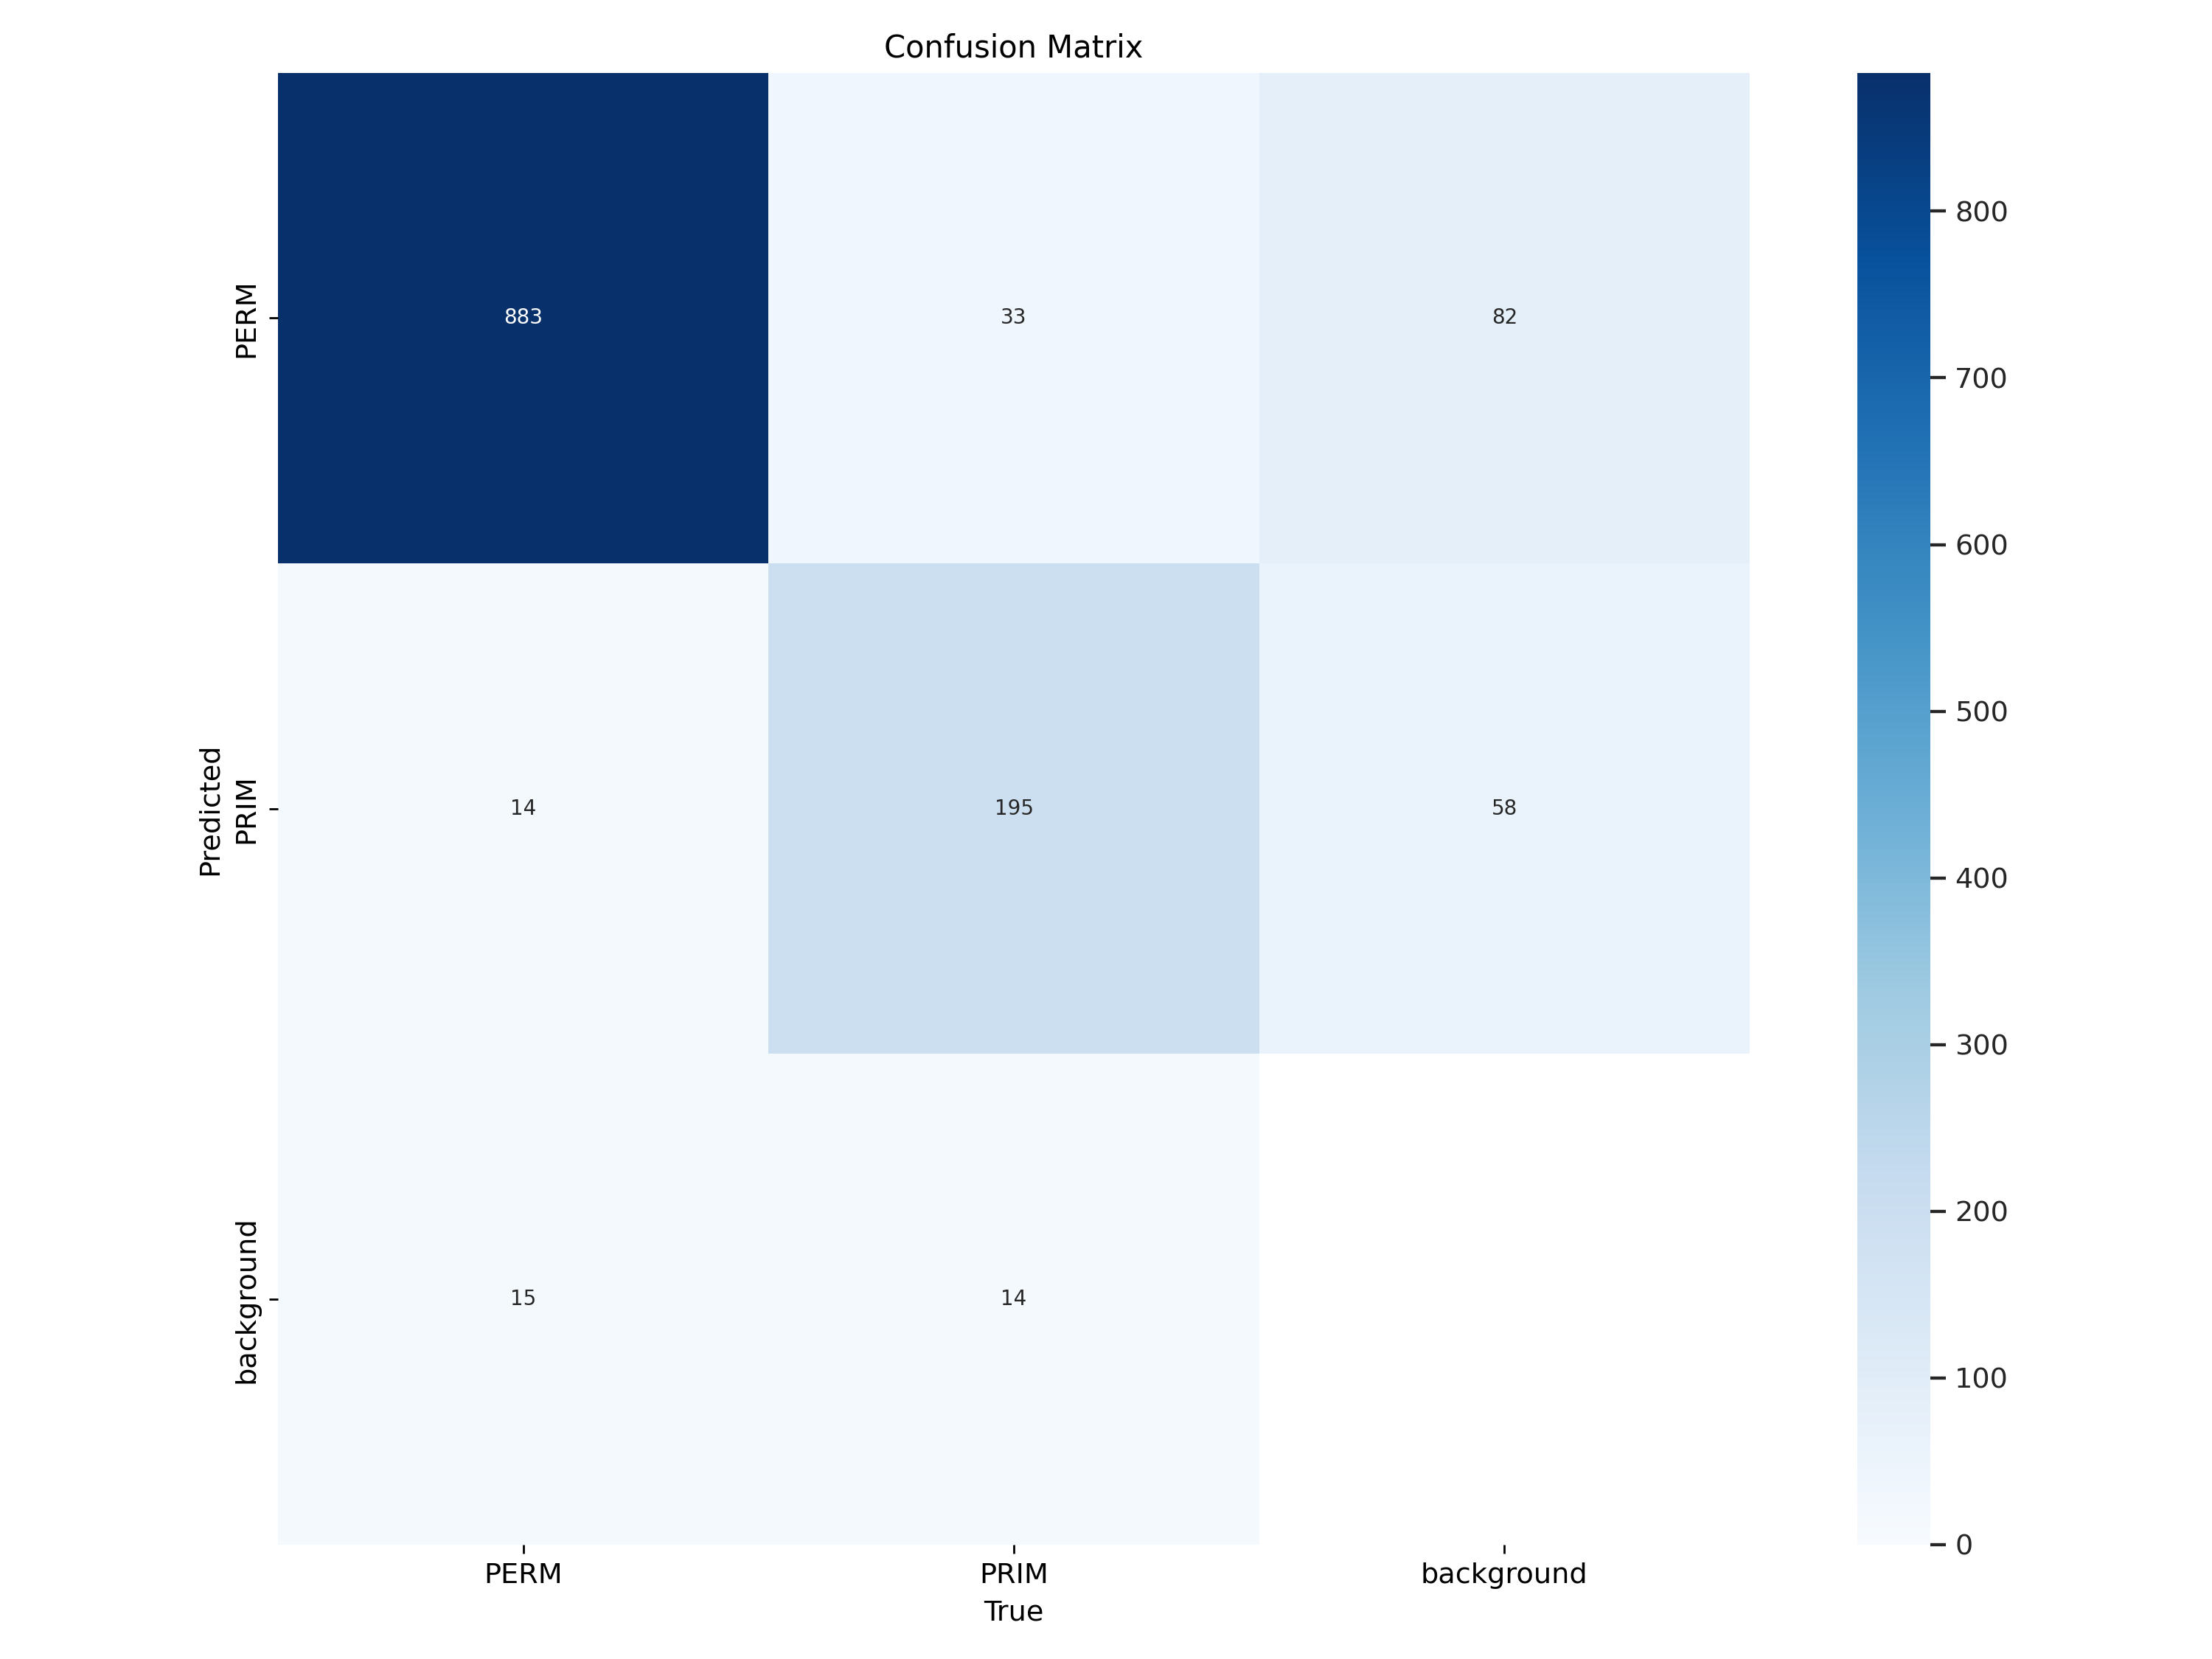

In [ ]:
%cd {HOME}

from IPython.display import Image

Image(filename=f'{HOME}/runs/detect/train2/confusion_matrix.png', width=600)

/content


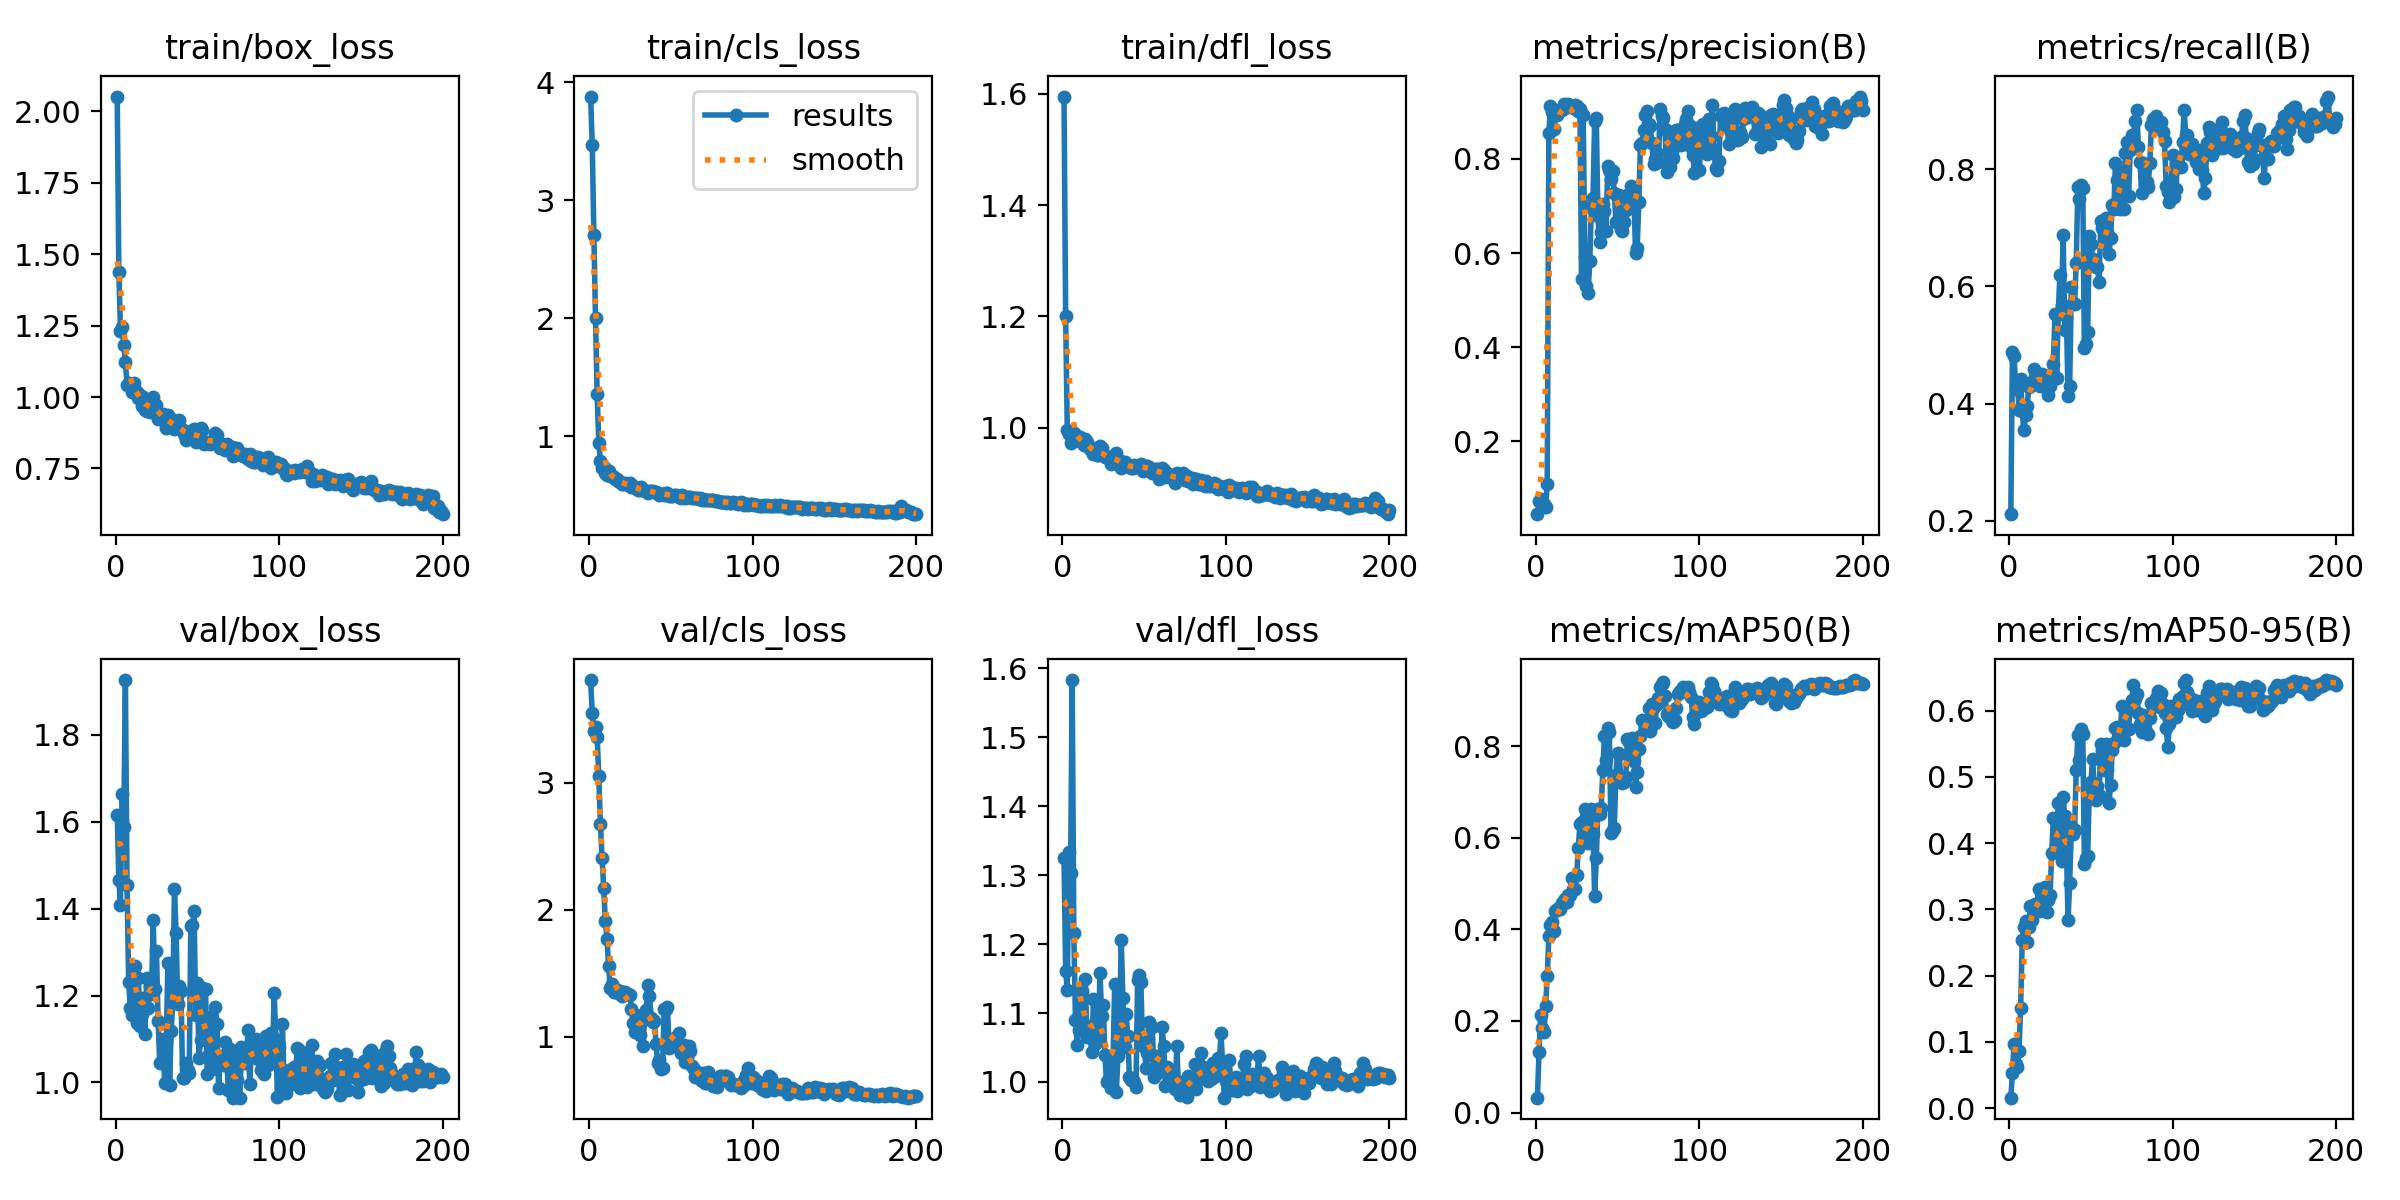

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train2/results.png', width=600)

## Inference with Custom Model

**NOTE:** Let's start by loading our newly trained model.

In [15]:
import cv2;
import matplotlib.pyplot as plt

image = cv2.imread('/content/drive/MyDrive/AI Dentistry - PHD Research/SAM/Testing/Dental-Testing-Images/Categories/category1.jpg')

In [7]:
!pip install ultralytics

from ultralytics import YOLO
import random

model = YOLO('/content/drive/MyDrive/AI Dentistry - PHD Research/SAM/YOLO MODELS/Tooth/best-identification.pt')
results = model(source=image, conf=0.25)


0: 384x640 6 PERMs, 49.8ms
Speed: 3.9ms preprocess, 49.8ms inference, 292.5ms postprocess per image at shape (1, 3, 384, 640)


In [ ]:
results[0].boxes.xyxy

tensor([[ 564.6661,  539.8046,  661.7164,  661.5177],
        [ 743.5004,  540.6761,  807.4415,  674.7789],
        [1174.7743,  540.8583, 1241.9551,  675.6315],
        [1244.9663,  558.7567, 1319.5901,  662.1891],
        [1268.6464,  673.1281, 1417.1146,  829.4710],
        [1042.5198,  695.1078, 1109.2227,  895.0942],
        [ 283.1529,  662.0359,  441.6239,  837.9925],
        [ 417.0451,  651.0845,  599.8630,  880.1956],
        [1125.7910,  347.7187, 1253.2312,  509.4643],
        [ 666.3475,  558.4739,  738.9702,  665.8329],
        [1325.2395,  553.5912, 1424.8130,  656.1328],
        [ 389.0662,  345.7517,  525.6567,  502.6323],
        [1469.4598,  351.3210, 1606.8843,  499.3070],
        [1111.8156,  718.6365, 1189.2548,  936.5009],
        [1189.2014,  718.1777, 1288.6608,  895.8481],
        [1545.2860,  664.7617, 1702.3353,  829.9097],
        [1384.8984,  646.0548, 1563.9178,  873.3667],
        [ 716.1816,  692.6590,  797.9912,  767.8887],
        [ 775.3394,  734.684


0: 384x640 32 PERMs, 10.3ms
Speed: 2.5ms preprocess, 10.3ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)


SupervisionWarnings: BoundingBoxAnnotator is deprecated: `BoundingBoxAnnotator` is deprecated and has been renamed to `BoxAnnotator`. `BoundingBoxAnnotator` will be removed in supervision-0.26.0.


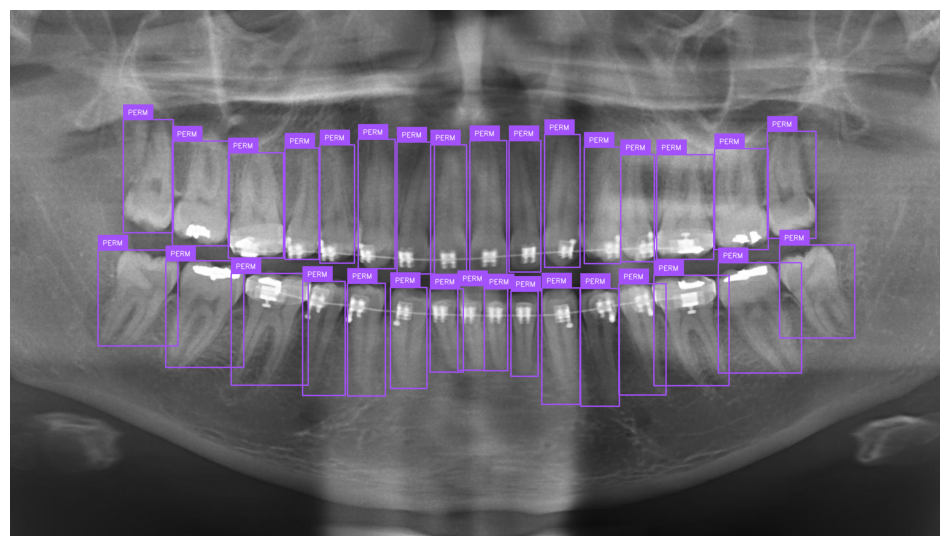

In [16]:
import cv2
import supervision as sv

model = YOLO('/content/drive/MyDrive/AI Dentistry - PHD Research/SAM/YOLO MODELS/Tooth/best-identification.pt')
results = model(image)[0]
detections = sv.Detections.from_ultralytics(results)

bounding_box_annotator = sv.BoundingBoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = bounding_box_annotator.annotate(
    scene=image, detections=detections)
annotated_image = label_annotator.annotate(
    scene=annotated_image, detections=detections)

sv.plot_image(annotated_image)

While your deployment is processing, checkout the deployment docs to take your model to most destinations https://docs.roboflow.com/inference